In [842]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

In [843]:
MODEL_COLORS = {
    "actual":"#0055ff",
    "ECMWF":"#de0000",
    "rf_prediction":"#2f9901",
    "xgb_predicted":"#c77cff",
    "SSA-LSTM":"#ff7700",
    "ensemble_xgb_pred":"#00B5B8",
}

MODEL_LABELS = {
    "ECMWF": "ECMWF",
    "rf_prediction": "RF",
    "xgb_predicted": "XGB",
    "SSA-LSTM": "SSA-LSTM",
    "ensemble_xgb_pred": "Ansamblis",
}

KATEGORIJU_TVARKA = [
    "0: Nėra lietaus (<0,6 mm)",
    "1: Silpnas (0,6-4 mm)",
    "2: Vidutinis (4-30 mm)",
    "3: Stiprus (>30 mm)",
]

In [944]:
df = pd.read_csv("All_predictions.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'rf_prediction',
 'actual',
 'ECMWF',
 'xgb_predicted',
 'SSA-LSTM']

In [945]:
pradzia = df['observationTime'].min()
pabaiga = df['observationTime'].max()
print(pradzia, pabaiga)

2024-08-11 00:00:00 2026-01-30 00:00:00


In [946]:
df.tail()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
533,2026-01-26,1.137,1.9,2.256399,1.226669,0.979986
534,2026-01-27,3.763,3.8,5.037111,3.614739,3.076599
535,2026-01-28,4.277,6.0,5.703954,3.818949,3.662336
536,2026-01-29,1.372,0.0,0.669112,0.865018,0.554164
537,2026-01-30,0.169,0.0,0.035326,0.117194,0.041875


In [960]:
def gauti_kategorija_pagal_kvantili(x, q25, q50, q75):
    if x == 0:
        return "Nėra lietaus"
    elif x <= q25:
        return rf"iki $Q_1$ (≤{q25:.1f} mm)"
    elif x <= q50:
        return rf"$Q_1$–$Q_2$ (≤{q50:.1f} mm)"
    elif x <= q75:
        return rf"$Q_2$–$Q_3$ (≤{q75:.1f} mm)"
    else:
        return rf"nuo $Q_3$ (>{q75:.1f} mm)"


def gauti_kategoriju_ribas(data, target_col="actual"):
    nenuliai = data[data[target_col] > 0][target_col]
    q25 = nenuliai.quantile(0.25)
    q50 = nenuliai.quantile(0.50)
    q75 = nenuliai.quantile(0.75)
    return q25, q50, q75

def _kategoriju_tvarka(q25, q50, q75):
    return [
        "Nėra lietaus",
        rf"iki $Q_1$ (≤{q25:.1f} mm)",
        rf"$Q_1$–$Q_2$ (≤{q50:.1f} mm)",
        rf"$Q_2$–$Q_3$ (≤{q75:.1f} mm)",
        rf"nuo $Q_3$ (>{q75:.1f} mm)",
    ]

def prideti_klaidas(data, model_cols, target_col="actual"):
    d = data.copy()
    for col in model_cols:
        d[f"Error_{col}"] = d[col] - d[target_col]
    return d


def calculate_metrics(y_true, y_pred, model_name):
    return {
        "Modelis": model_name,
        "R^2":  round(r2_score(y_true, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "r_s":  round(stats.spearmanr(y_true, y_pred)[0], 4),
    }


def metrikos_lentele(data, model_cols, target_col="actual"):
    results = [calculate_metrics(data[target_col], data[m], MODEL_LABELS.get(m, m))
               for m in model_cols]
    return pd.DataFrame(results)

# Grafikų funckijos

In [920]:
def plot_prognozes_matplotlib(data, model_cols, target_col="actual", nuo=None, iki=None):
    d = data.copy()
    if nuo is not None:
        d = d[d['observationTime'] >= pd.Timestamp(nuo)]
    if iki is not None:
        d = d[d['observationTime'] <= pd.Timestamp(iki)]

    if d.empty:
        print("Pagal nurodytus rėžius duomenų nerasta.")
        return

    width_inch = 17 / 2.54
    height_inch = width_inch * 0.3

    fig, ax = plt.subplots(figsize=(width_inch, height_inch))
    ax.plot(d['observationTime'], d[target_col],
            label='Tikra', color=MODEL_COLORS['actual'], linewidth=1)
    
    linestyles = ['--', '-.', ':', '--']
    for i, col in enumerate(model_cols):
        current_style = linestyles[i % len(linestyles)]
        
        ax.plot(d['observationTime'], d[col],
                label=MODEL_LABELS.get(col, col),
                color=MODEL_COLORS.get(col, None),
                linewidth=0.8, 
                linestyle=current_style)

    ax.set_xlim(d['observationTime'].min(), d['observationTime'].max())
    ax.set_xlabel('')
    ax.set_ylabel('Krituliai (mm)', fontsize=7)
    
    title = 'Modelių prognozių palyginimas'
    if nuo or iki:
        title += f"  ({nuo or '...'} — {iki or '...'})"

    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, ncol=2)
    ax.tick_params(axis='both', labelsize=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.grid(True, linestyle='-', alpha=0.2)
    
    plt.tight_layout()
    plt.savefig('modeliu_palyginimas_ansambliu.png', dpi=300, bbox_inches='tight')
    plt.show()

In [848]:
def plot_prognozes_plotly(data, model_cols, target_col="actual"):
    dash_styles = ['dot', 'dash', 'dashdot', 'longdash', 'longdashdot']
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=data['observationTime'], y=data[target_col],
        name='Tikra', line=dict(color=MODEL_COLORS['actual'], width=1.5)
    ))
    for i, col in enumerate(model_cols):
        fig.add_trace(go.Scatter(
            x=data['observationTime'], y=data[col],
            name=MODEL_LABELS.get(col, col),
            line=dict(color=MODEL_COLORS.get(col), width=1, dash=dash_styles[i % len(dash_styles)])
        ))
    fig.update_layout(
        title='Modelių prognozių palyginimas',
        xaxis_title='Data', yaxis_title='Krituliai (mm)',
        hovermode='x unified',
        xaxis=dict(rangeslider=dict(visible=True)),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )
    fig.show()

In [849]:
def plot_error_heatmap(data, model_cols, target_col="actual"):
    d = prideti_klaidas(data, model_cols, target_col)
    error_cols = [f"Error_{c}" for c in model_cols]
    heatmap_data = d[error_cols].T
    heatmap_data.index = [MODEL_LABELS.get(c, c) for c in model_cols]
    plt.figure(figsize=(18, 4))
    sns.heatmap(heatmap_data, cmap='coolwarm', center=0,
                cbar_kws={'label': 'Paklaida (mm)'})
    plt.title('Modelių prognozių paklaidų šilumos žemėlapis', fontsize=14)
    plt.xlabel('Diena')
    plt.ylabel('Modeliai')
    plt.tight_layout()
    plt.show()

In [951]:
def plot_monthly_error_heatmap(data, model_cols, target_col="actual"):
    d = prideti_klaidas(data, model_cols, target_col)
    d['Metai_Mėnesis'] = d['observationTime'].dt.to_period('M')
    
    min_date = d['observationTime'].min()
    if min_date.day != 1:
        pirmas_nepilnas_muo = min_date.to_period('M')
        d = d[d['Metai_Mėnesis'] > pirmas_nepilnas_muo]

    error_cols = [f"Error_{c}" for c in model_cols]
    monthly = d.groupby('Metai_Mėnesis')[error_cols].mean().T
    monthly.index = [MODEL_LABELS.get(c, c) for c in model_cols]
    monthly.columns = monthly.columns.to_timestamp().strftime('%m')
    annot_labels = monthly.applymap(lambda x: f"{x:.2f}".replace('.', ','))

    width_inch = 17 / 2.54
    height_inch = width_inch * 0.3

    fig, ax = plt.subplots(figsize=(width_inch, height_inch))
    
    sns.heatmap(monthly, cmap='coolwarm', center=0,
                annot=annot_labels, fmt="", ax=ax,
                annot_kws={'size': 7},
                cbar_kws={'label': 'Vidutinė mėnesio paklaida (mm)'})
    
    cbar_ax = ax.collections[0].colorbar.ax
    cbar_ax.tick_params(labelsize=6.5)
    cbar_ax.yaxis.label.set_size(7)

    cbar_ticks = cbar_ax.get_yticks()
    cbar_ax.set_yticklabels(
        [f"{t:.1f}".replace('.', ',') for t in cbar_ticks],
        fontsize=6.5
    )

    plt.title('Vidutinė modelių prognozių paklaida pagal mėnesį', fontsize=9)
    plt.xlabel('Mėnuo', fontsize=8)
    plt.ylabel('', fontsize=7)
    ax.tick_params(axis='both', labelsize=8)
    plt.xticks(rotation=0) 
    plt.tight_layout()
    plt.savefig('plot_monthly_error_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

In [963]:
def plot_boxplot_klaidos(data, model_cols, target_col="actual", standartizuotos=False):
    d = data.copy()
    for col in model_cols:
        if standartizuotos:
            d[f"Error_{col}"] = np.where(
                d[target_col] > 0,
                ((d[col] - d[target_col]) / d[target_col]) * 100,
                d[col] - d[target_col]
            )
        else:
            d[f"Error_{col}"] = d[col] - d[target_col]

    q25, q50, q75 = gauti_kategoriju_ribas(data, target_col)

    d["Kritulių_Dydis"] = pd.Categorical(
        d[target_col].apply(lambda x: gauti_kategorija_pagal_kvantili(x, q25, q50, q75)),
        categories=_kategoriju_tvarka(q25, q50, q75),
        ordered=True
    )

    error_cols = [f"Error_{c}" for c in model_cols]
    df_long = pd.melt(d, id_vars=["Kritulių_Dydis"], value_vars=error_cols,
                      var_name="Modelis", value_name="Paklaida")
    df_long["Modelis"] = df_long["Modelis"].str.replace("Error_", "", regex=False)
    df_long["Modelis"] = df_long["Modelis"].map(lambda x: MODEL_LABELS.get(x, x))

    palette = [MODEL_COLORS.get(c) for c in model_cols]

    width_inch = 17 / 2.54
    height_inch = width_inch * 0.45

    plt.figure(figsize=(width_inch, height_inch))
    sns.boxplot(x="Kritulių_Dydis", y="Paklaida", hue="Modelis",
                data=df_long, palette=palette, showfliers=False)
    plt.axhline(0, color="red", linestyle="--", alpha=0.7)
    title = ("Standartizuotos modelių paklaidos pagal kritulių dydį"
             if standartizuotos else
             "Modelių paklaidos priklausomai nuo tikrojo kritulių dydžio")
    plt.title(title, fontsize=10)
    plt.xlabel("Tikras kritulių kiekis", fontsize=8)
    plt.ylabel("Prognozės paklaida " + ("(%)" if standartizuotos else "(mm)"), fontsize=8)
    plt.tick_params(axis='both', labelsize=7.5)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Modelis", fontsize=7, title_fontsize=7)
    plt.gca().set_xticklabels([label.get_text().replace('.', ',') for label in plt.gca().get_xticklabels()])
    plt.tight_layout()

    plt.savefig('plot_boxplot_klaidos.png', dpi=300, bbox_inches='tight')

    plt.show()

In [852]:
def plot_density(data, model_cols, target_col="actual", xlim=(-20, 20)):
    d = prideti_klaidas(data, model_cols, target_col)
    plt.figure(figsize=(9, 5))
    for col in model_cols:
        sns.kdeplot(data=d[f"Error_{col}"],
                    label=MODEL_LABELS.get(col, col),
                    color=MODEL_COLORS.get(col),
                    linewidth=1, fill=False, alpha=1)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1,
                label='Ideali prognozė (Paklaida = 0)')
    plt.xlim(xlim)
    plt.title('Modelių prognozių paklaidų tankio pasiskirstymas', fontsize=11)
    plt.xlabel('Prognozės paklaida (mm)', fontsize=9)
    plt.ylabel('Tankis', fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.5, color='#cccccc')
    plt.legend(loc='upper right', fontsize=8.5)
    plt.tight_layout()
    plt.show()

In [916]:
def plot_cumsum(data, model_cols, target_col="actual"):
    d = data.copy()
    d['_actual_cum'] = d[target_col].cumsum()
    dash_styles = ['--', ':', '-.', (0, (5, 2)), (0, (3, 1, 1, 1))]

    width_inch = 17 / 2.54 / 2
    height_inch = width_inch * 0.95

    fig, ax = plt.subplots(figsize=(width_inch, height_inch), constrained_layout=True)
    ax.plot(d['observationTime'], d['_actual_cum'],
            label='Tikra', color=MODEL_COLORS['actual'], linewidth=1.5)
            
    metrics_list = []
    
    for i, col in enumerate(model_cols):
        d[f'_{col}_cum'] = d[col].cumsum()
        ax.plot(d['observationTime'], d[f'_{col}_cum'],
                label=MODEL_LABELS.get(col, col),
                color=MODEL_COLORS.get(col),
                linewidth=1, linestyle=dash_styles[i % len(dash_styles)])
        
        mbe = (d[col] - d[target_col]).mean()
        
        metrics_list.append({
            'Modelis': MODEL_LABELS.get(col, col),
            'MBE (mm)': round(mbe, 3),
        })

    ax.set_xlim(d['observationTime'].min())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_ylabel("Krituliai (mm)", fontsize=8)
    ax.set_xlabel("", fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.set_title("Kaupiamoji kritulių suma 2025-2026 m.", fontsize=10)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
    ax.legend(loc='upper left', fontsize=7.5, frameon=True,
              facecolor='white', framealpha=0.9)
              
    plt.savefig('plot_cumsum.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    metrics_df = pd.DataFrame(metrics_list).set_index('Modelis')
    return metrics_df

In [854]:
def plot_scatter_log(data, model_cols, target_col="actual"):
    n = len(model_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows),
                              sharex=True, sharey=True)
    axes = axes.flatten()
    x_val = np.log1p(data[target_col])
    for i, col in enumerate(model_cols):
        ax = axes[i]
        y_val = np.log1p(data[col].clip(lower=0))
        sns.regplot(x=x_val, y=y_val, ax=ax, color=MODEL_COLORS.get(col),
                    scatter_kws={'alpha': 0.4, 's': 8},
                    line_kws={'color': 'red', 'linewidth': 1.5, 'label': 'Modelio tendencija'})
        max_limit = max(x_val.max(), y_val.max())
        ax.plot([0, max_limit], [0, max_limit], color='gray', linestyle='--',
                alpha=0.7, label='Ideali prognozė')
        ax.set_title(f"{MODEL_LABELS.get(col, col)} vs Tikri duomenys",
                     fontsize=11, pad=8)
        ax.set_xlabel("log(Tikri krituliai + 1)", fontsize=9)
        ax.set_ylabel(f"log(Prognozė + 1)", fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.5, color='#cccccc')
        ax.tick_params(axis='both', labelsize=8)
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

In [941]:
def plot_qq(data, model_cols, target_col="actual"):
    n = len(model_cols)
    nrows = 1
    ncols = n

    width_inch = 17 / 2.54
    height_inch = width_inch * 0.3
    fig, axes = plt.subplots(nrows, ncols, figsize=(width_inch, height_inch))
    
    if n == 1:
        axes = [axes]
        
    actual_sorted = np.sort(data[target_col])
    global_max = actual_sorted.max()
    for col in model_cols:
        m_max = data[col].clip(lower=0).max()
        if m_max > global_max:
            global_max = m_max
    max_val = global_max * 1.05
    
    for i, col in enumerate(model_cols):
        ax = axes[i]
        model_sorted = np.sort(data[col].clip(lower=0))
        
        ax.scatter(actual_sorted, model_sorted,
                   color=MODEL_COLORS.get(col), s=5, alpha=1,
                   label=MODEL_LABELS.get(col, col), edgecolors='none')
        
        ax.plot([0, max_val], [0, max_val], color='gray', linestyle='--', linewidth=0.9,
                alpha=0.7, label='Ideali atitiktis (y=x)')
        
        ax.set_xlim(-0.2, max_val)
        ax.set_ylim(-0.2, max_val)

        tick_step = 15
        ticks = np.arange(0, max_val, tick_step)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f"{MODEL_LABELS.get(col, col)}", fontsize=8)
        ax.set_xlabel("Tikros reikšmės (mm)", fontsize=7)
        
        if i == 0:
            ax.set_ylabel("Prognozuotos reikšmės (mm)", fontsize=7)
            # ax.legend(loc='upper left', fontsize=7)
        else:
            ax.set_ylabel("")
            
        ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
        ax.tick_params(axis='both', labelsize=6.5)
            
    plt.tight_layout()
    plt.savefig('plot_qq.png', dpi=300, bbox_inches='tight')
    plt.show()


In [970]:
def plot_confusion_matrices_rain(data, target_col, model_cols, rain_threshold=0.0):
    n = len(model_cols)

    width_inch = 17 / 2.54
    height_inch = width_inch * 0.3

    fig, axes = plt.subplots(1, n, figsize=(width_inch, height_inch), squeeze=False)
    axes = axes.flatten()
    results = []
    
    for idx, col in enumerate(model_cols):
        ax = axes[idx]
        
        y_true_bin = (data[target_col] > rain_threshold).astype(int)
        y_pred_bin = (data[col] > rain_threshold).astype(int)
        
        results.append({
            "Modelis":    MODEL_LABELS.get(col, col),
            "Accuracy":   round(accuracy_score(y_true_bin, y_pred_bin), 3),
            "Precision":  round(precision_score(y_true_bin, y_pred_bin, zero_division=0), 3),
            "Recall":     round(recall_score(y_true_bin, y_pred_bin, zero_division=0), 3),
            "F1-Score":   round(f1_score(y_true_bin, y_pred_bin, zero_division=0), 3),
        })
        
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        rodyti_y_labels = ['Nelyja', 'Lyja'] if idx == 0 else False
        
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['Nelyja', 'Lyja'], 
                    yticklabels=rodyti_y_labels,
                    cbar=False, ax=ax,
                    annot_kws={'size': 10})
        
        ax.set_title(f"{MODEL_LABELS.get(col, col)}", fontsize=9)
        ax.set_xlabel("Prognozė", fontsize=9) 

        if idx == 0:
            ax.set_ylabel("Tikra reikšmė", fontsize=9)
        else:
            ax.set_ylabel("")
            
        ax.tick_params(axis='both', labelsize=8)
        
    plt.tight_layout()
    plt.savefig('plot_confusion_matrices_rain.png', dpi=300, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(results)

In [857]:
def plot_confusion_matrices_kategorijos(data, model_cols, target_col="actual"):
    d = data.copy()

    q25, q50, q75 = gauti_kategoriju_ribas(data, target_col)
    kategorijos = _kategoriju_tvarka(q25, q50, q75)
    short_labels = ["Nėra", "iki Q25", "Q25–50", "Q50–75", "nuo Q75"]

    d["Cat_Actual"] = d[target_col].apply(
        lambda x: gauti_kategorija_pagal_kvantili(x, q25, q50, q75)
    )
    for col in model_cols:
        d[f"Cat_{col}"] = d[col].apply(
            lambda x: gauti_kategorija_pagal_kvantili(x, q25, q50, q75)
        )

    n = len(model_cols)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
    axes = axes.flatten()

    for idx, col in enumerate(model_cols):
        cm = confusion_matrix(d["Cat_Actual"], d[f"Cat_{col}"], labels=kategorijos)
        cm_pct = np.nan_to_num(cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]) * 100
        labels = np.asarray(
            [f"{c}\n({p:.1f}%)" for c, p in zip(cm.flatten(), cm_pct.flatten())]
        ).reshape(5, 5)
        sns.heatmap(cm_pct, annot=labels, fmt="", cmap="Blues",
                    ax=axes[idx], xticklabels=short_labels,
                    yticklabels=short_labels,
                    cbar=False, linewidths=0.5, linecolor="gray")
        axes[idx].set_title(f"{MODEL_LABELS.get(col, col)} klasifikavimo matrica", fontsize=12)
        axes[idx].set_xlabel("Prognozuota kategorija", fontsize=10)
        axes[idx].set_ylabel("Tikra kategorija", fontsize=10)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        "Klasifikavimo matricos (% pagal faktinę kategoriją)\n"
        f"iki Q25 ≤{q25:.1f} mm | Q25–Q50 ≤{q50:.1f} mm | "
        f"Q50–Q75 ≤{q75:.1f} mm | nuo Q75 >{q75:.1f} mm",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

# Bendra aibė pagal LSTM

In [858]:
TARGET_COL = "actual"
MODEL_COLS = ["ECMWF", "rf_prediction", "xgb_predicted", "SSA-LSTM"]

In [859]:
metrikos = metrikos_lentele(df, MODEL_COLS, TARGET_COL)
print(metrikos.to_string(index=False))

 Modelis    R^2    MAE   RMSE    r_s
   ECMWF 0.3570 1.2996 3.0837 0.7410
      RF 0.5118 1.2241 2.6869 0.7099
     XGB 0.4735 1.2482 2.7904 0.6897
SSA-LSTM 0.5348 1.1835 2.6230 0.6510


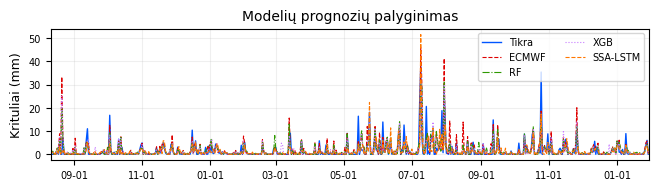

In [860]:
plot_prognozes_matplotlib(df, MODEL_COLS)

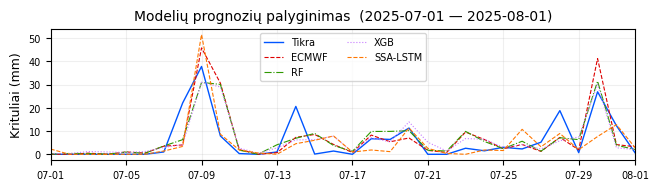

In [861]:
plot_prognozes_matplotlib(df, MODEL_COLS, nuo="2025-07-01", iki="2025-08-01")

In [862]:
plot_prognozes_plotly(df, MODEL_COLS)

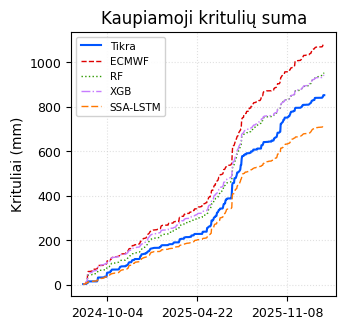

,MBE (mm)
Modelis,
ECMWF,0.430
RF,0.184
XGB,0.165
SSA-LSTM,-0.252


In [ ]:
plot_cumsum(df, MODEL_COLS)

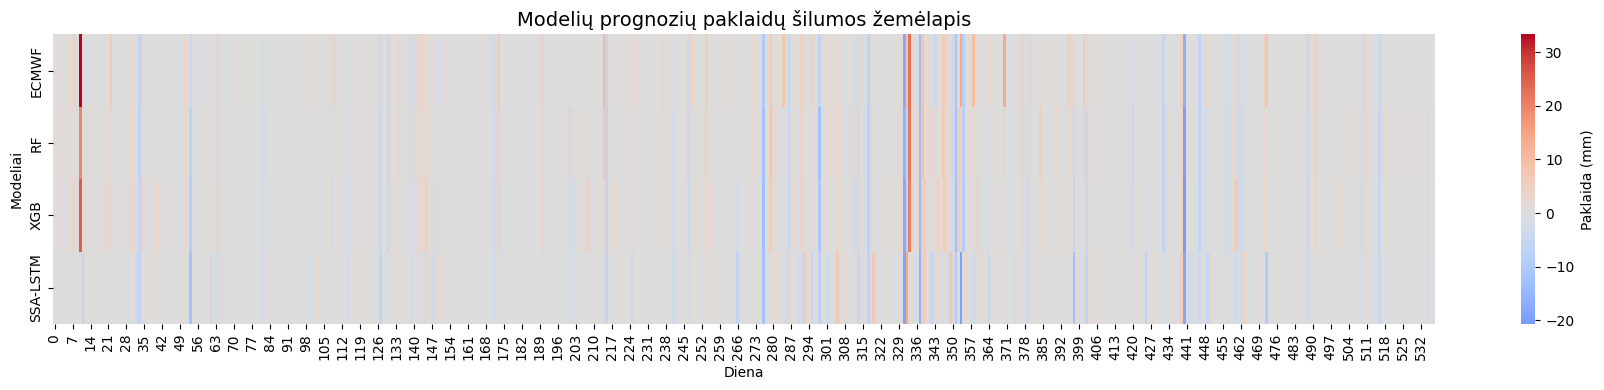

In [ ]:
plot_error_heatmap(df, MODEL_COLS)

C:\Users\rugil\AppData\Local\Temp\ipykernel_14692\4212200320.py:14: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



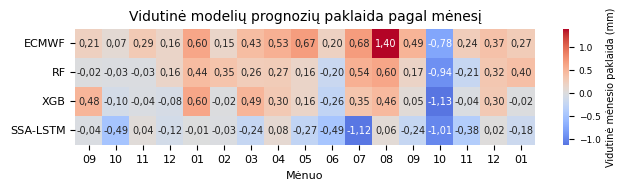

In [ ]:
plot_monthly_error_heatmap(df, MODEL_COLS)

C:\Users\rugil\AppData\Local\Temp\ipykernel_14692\3200162826.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



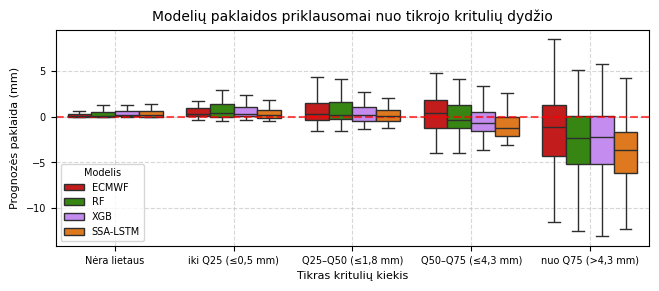

In [866]:
plot_boxplot_klaidos(df, MODEL_COLS)

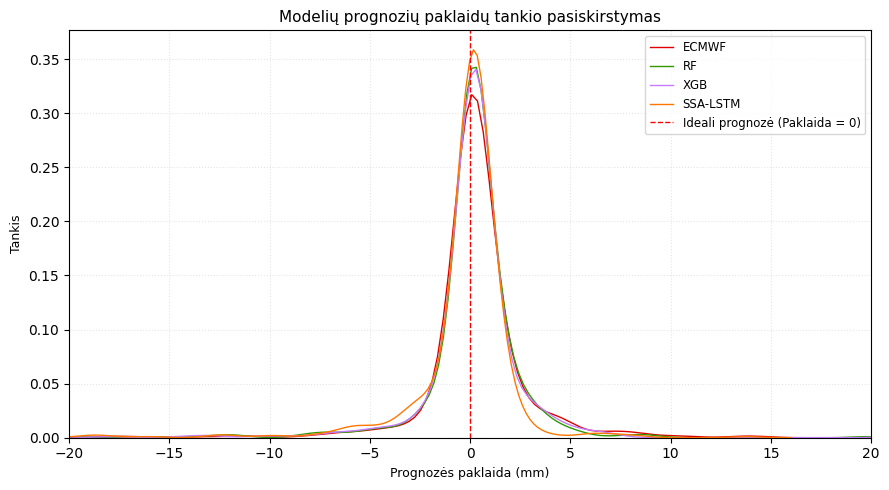

In [ ]:
plot_density(df, MODEL_COLS)

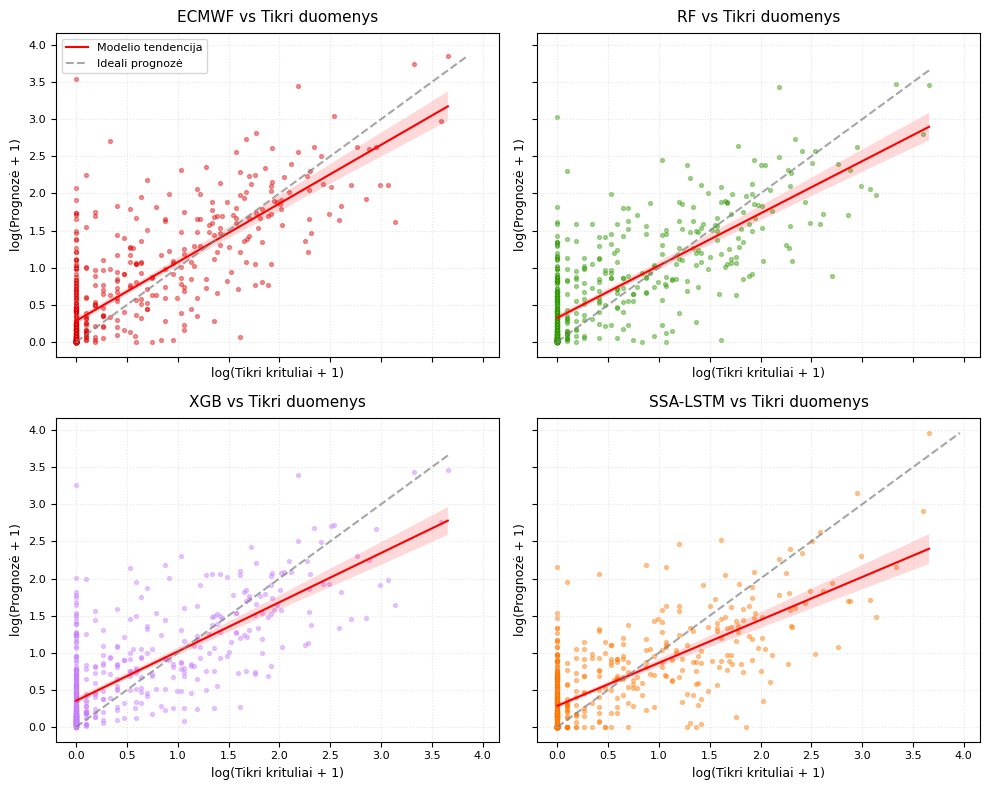

In [ ]:
plot_scatter_log(df, MODEL_COLS)

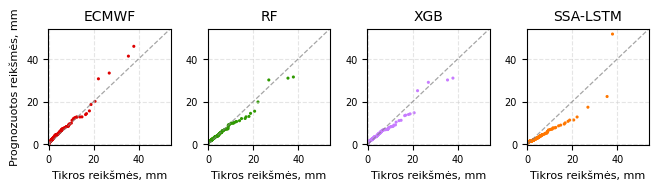

In [ ]:
plot_qq(df, MODEL_COLS)

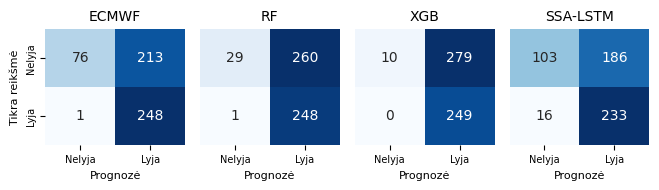

 Modelis  Accuracy  Precision  Recall  F1-Score
   ECMWF     0.602      0.538   0.996     0.699
      RF     0.515      0.488   0.996     0.655
     XGB     0.481      0.472   1.000     0.641
SSA-LSTM     0.625      0.556   0.936     0.698


In [ ]:
klasif = plot_confusion_matrices_rain(df, TARGET_COL, MODEL_COLS)
print(klasif.to_string(index=False))

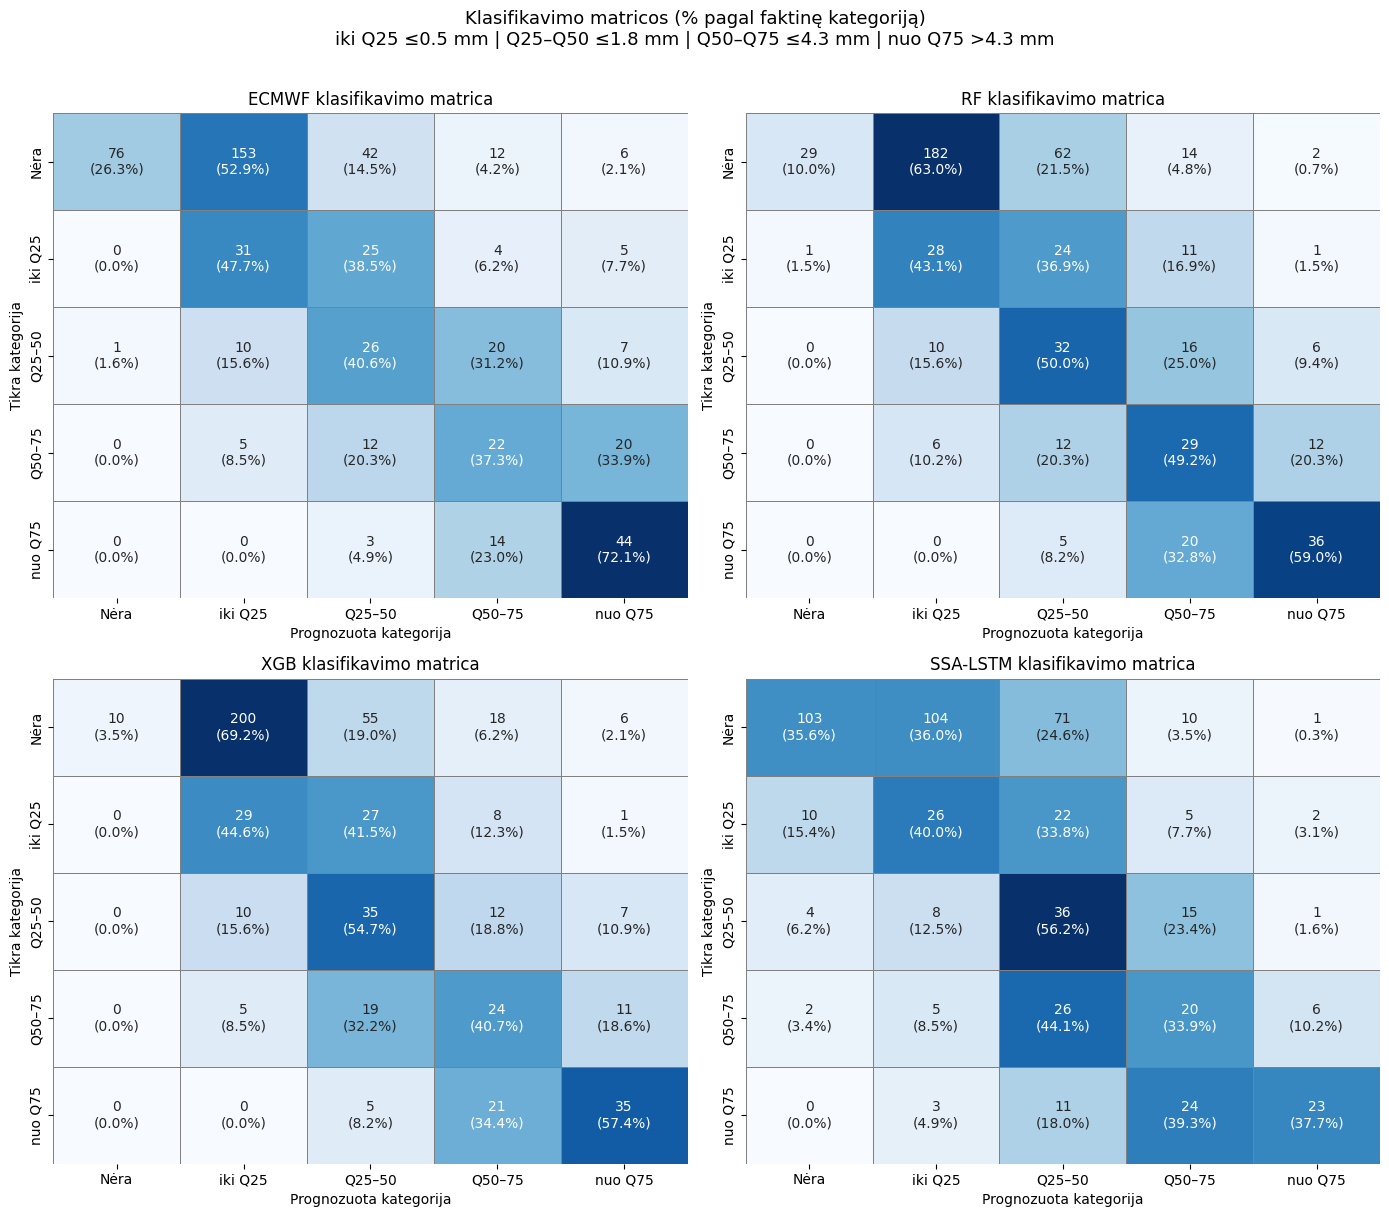

In [ ]:
plot_confusion_matrices_kategorijos(df, MODEL_COLS)

# Tik test aibė (paskutiniai metai)

In [885]:
paskutine_data = df['observationTime'].max()
pries_metus = paskutine_data - pd.Timedelta(days=365)
df_365 = df[(df['observationTime'] > pries_metus) & (df['observationTime'] <= paskutine_data)]
print(f"Paskutinių 12 mėn. duomenų taškai: {len(df_365)}")

Paskutinių 12 mėn. duomenų taškai: 365


In [948]:
df_365.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
173,2025-01-31,5.088,1.0,7.871188,5.512503,0.378813
174,2025-02-01,4.751,5.2,5.009430,3.659034,3.871656
175,2025-02-02,1.371,0.9,0.790931,0.598205,1.199541
176,2025-02-03,1.324,0.5,0.747081,0.675376,0.213157
177,2025-02-04,0.328,0.1,0.472754,0.325430,0.384124


In [886]:
metrikos_365 = metrikos_lentele(df_365, MODEL_COLS, TARGET_COL)
print(metrikos_365.to_string(index=False))

 Modelis    R^2    MAE   RMSE    r_s
   ECMWF 0.4846 1.4452 3.1535 0.7647
      RF 0.5520 1.3928 2.9401 0.7325
     XGB 0.5523 1.3588 2.9392 0.7228
SSA-LSTM 0.5368 1.3708 2.9895 0.6640


In [887]:
def add_skill_score(metrics_df, ref_model_name="ECMWF"):
    df = metrics_df.copy()
    
    if ref_model_name not in df['Modelis'].values:
        raise ValueError(f"Modelis '{ref_model_name}' nerastas stulpelyje 'Modelis'.")
        
    rmse_ref = df.loc[df['Modelis'] == ref_model_name, 'RMSE'].values[0]
    
    df['SS (%)'] = ((rmse_ref - df['RMSE']) / rmse_ref) * 100
    df['SS (%)'] = df['SS (%)'].round(4)
    
    return df


metrikos_365 = metrikos_lentele(df_365, MODEL_COLS, TARGET_COL)
metrikos_su_ss = add_skill_score(metrikos_365, ref_model_name="ECMWF")
print(metrikos_su_ss.to_string(index=False))

 Modelis    R^2    MAE   RMSE    r_s  SS (%)
   ECMWF 0.4846 1.4452 3.1535 0.7647  0.0000
      RF 0.5520 1.3928 2.9401 0.7325  6.7671
     XGB 0.5523 1.3588 2.9392 0.7228  6.7956
SSA-LSTM 0.5368 1.3708 2.9895 0.6640  5.2006


In [888]:
plot_prognozes_plotly(df_365, MODEL_COLS)

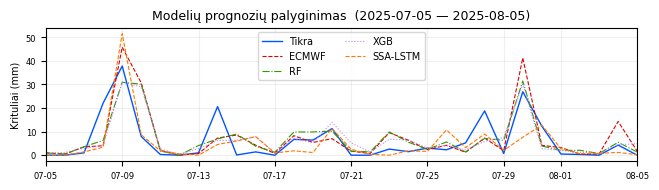

In [896]:
plot_prognozes_matplotlib(df_365, MODEL_COLS, nuo="2025-07-05", iki="2025-08-05")

C:\Users\rugil\AppData\Local\Temp\ipykernel_14692\4043634112.py:14: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

C:\Users\rugil\AppData\Local\Temp\ipykernel_14692\4043634112.py:31: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



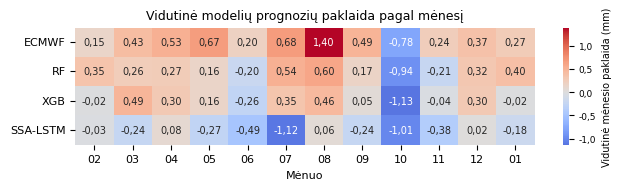

In [952]:
plot_monthly_error_heatmap(df_365, MODEL_COLS)

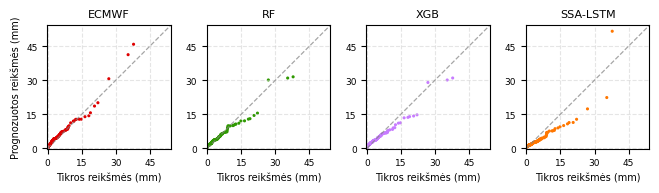

In [942]:
plot_qq(df_365, MODEL_COLS)

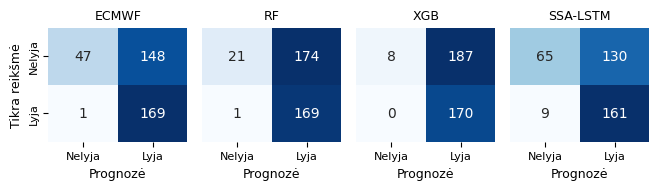

,Modelis,Accuracy,Precision,Recall,F1-Score
0,ECMWF,0.592,0.533,0.994,0.694
1,RF,0.521,0.493,0.994,0.659
2,XGB,0.488,0.476,1.000,0.645
3,SSA-LSTM,0.619,0.553,0.947,0.698


In [971]:
plot_confusion_matrices_rain(df_365, TARGET_COL, MODEL_COLS)

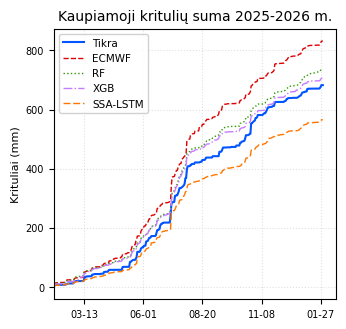

,MBE (mm)
Modelis,
ECMWF,0.408
RF,0.153
XGB,0.066
SSA-LSTM,-0.320


In [917]:
plot_cumsum(df_365, MODEL_COLS)

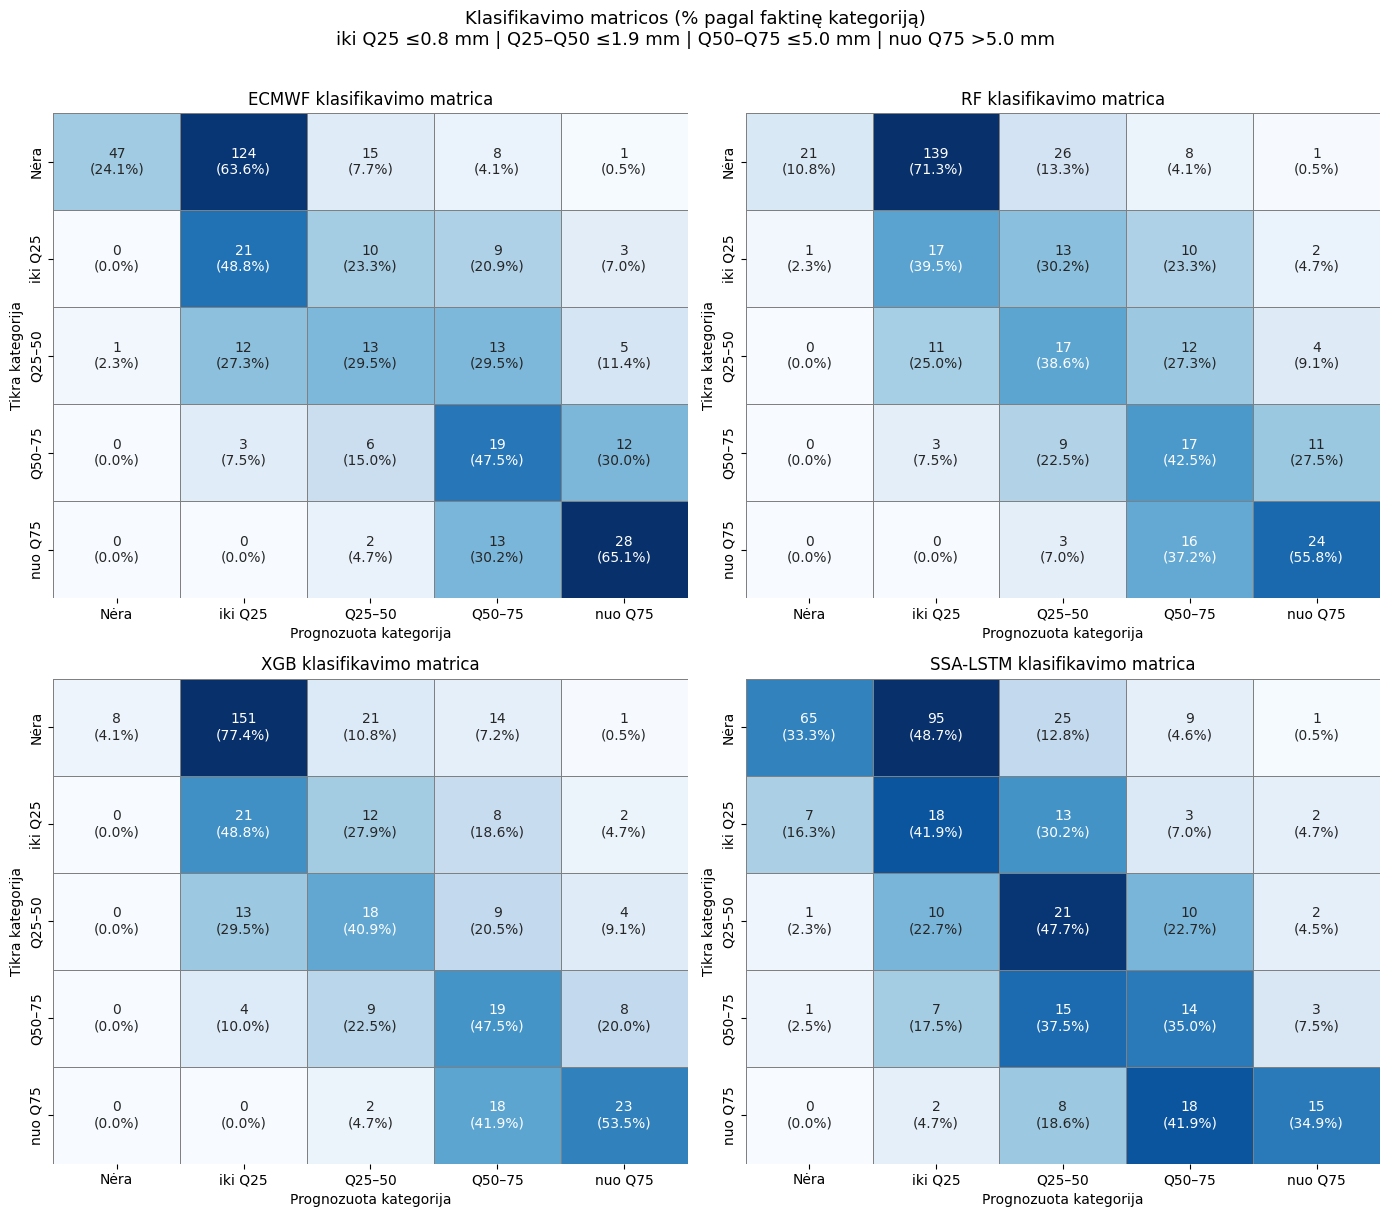

In [821]:
plot_confusion_matrices_kategorijos(df_365, MODEL_COLS)

C:\Users\rugil\AppData\Local\Temp\ipykernel_14692\1893780165.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



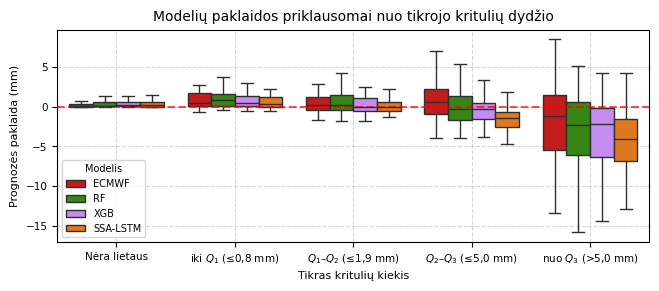

In [964]:
plot_boxplot_klaidos(df_365, MODEL_COLS)

# Modelis, be tarsos, didesne aibe

In [823]:
df_without = pd.read_csv("All_predictions_without.csv")
df_without['observationTime'] = pd.to_datetime(df['observationTime'])
df_without.columns.to_list()

['observationTime',
 'rf_prediction',
 'actual',
 'ECMWF',
 'xgb_predicted',
 'SSA-LSTM']

In [824]:
metrikos = metrikos_lentele(df_without, MODEL_COLS, TARGET_COL)
print(metrikos.to_string(index=False))

 Modelis    R^2    MAE   RMSE    r_s
   ECMWF 0.3570 1.2996 3.0837 0.7410
      RF 0.4356 1.2656 2.8891 0.6947
     XGB 0.4542 1.2875 2.8412 0.6911
SSA-LSTM 0.3904 1.4913 3.0027 0.6032


# Modelis, be tarsos, mazesne aibe

In [826]:
paskutine_data = df_without['observationTime'].max()
pries_metus = paskutine_data - pd.Timedelta(days=365)
df_without_365 = df_without[(df_without['observationTime'] > pries_metus) & (df_without['observationTime'] <= paskutine_data)]
print(f"Paskutinių 12 mėn. duomenų taškai: {len(df_without_365)}")

Paskutinių 12 mėn. duomenų taškai: 365


In [827]:
metrikos_df_without_365 = metrikos_lentele(df_without_365, MODEL_COLS, TARGET_COL)
print(metrikos_df_without_365.to_string(index=False))

 Modelis    R^2    MAE   RMSE    r_s
   ECMWF 0.4846 1.4452 3.1535 0.7647
      RF 0.4792 1.4195 3.1700 0.7212
     XGB 0.5114 1.4178 3.0705 0.7303
SSA-LSTM 0.3970 1.6923 3.4112 0.6032


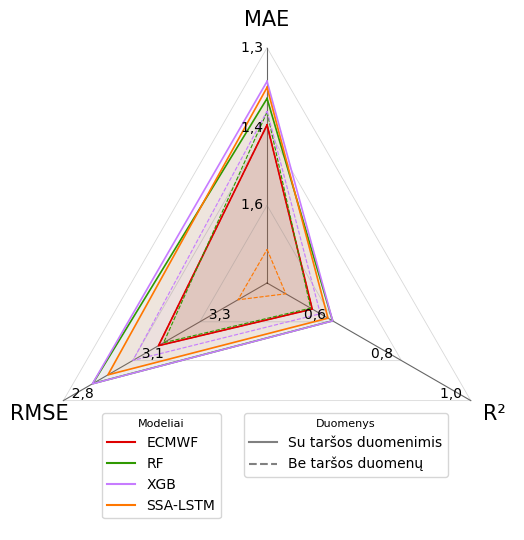

In [899]:
def plot_radar_3d_cube(data_with, data_without, model_cols, target_col="actual"):
    rows_with    = [calculate_metrics(data_with[target_col],    data_with[col],    col)               for col in model_cols]
    rows_without = [calculate_metrics(data_without[target_col], data_without[col], col + "_without")  for col in model_cols]
    
    metrics_df = pd.DataFrame(rows_with + rows_without).set_index("Modelis")
    metric_keys   = ["MAE", "R^2", "RMSE"] 

    metric_labels = ["MAE", "R²", "RMSE"]
    invert_keys   = {"MAE", "RMSE"}

    mins = metrics_df[metric_keys].min().copy()
    maxs = metrics_df[metric_keys].max().copy()
    ranges = maxs - mins

    adjusted_mins = mins.copy()
    adjusted_maxs = maxs.copy()
    
    for k in invert_keys:
        adjusted_mins[k] = max(0, adjusted_mins[k] - ranges[k] * 0.2)
        adjusted_maxs[k] = adjusted_maxs[k] + ranges[k] * 0.2
    
    adjusted_mins["R^2"] = max(0, adjusted_mins["R^2"] - ranges["R^2"] * 0.4)
    adjusted_maxs["R^2"] = 1.01

    normalized = pd.DataFrame(index=metrics_df.index)
    for k in metric_keys:
        if k in invert_keys:
            normalized[k] = 1.0 - ((metrics_df[k] - adjusted_mins[k]) / (adjusted_maxs[k] - adjusted_mins[k]))
        else:
            normalized[k] = (metrics_df[k] - adjusted_mins[k]) / (adjusted_maxs[k] - adjusted_mins[k])

    angles = np.linspace(0, 2 * np.pi, len(metric_keys), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 5.5), subplot_kw=dict(polar=True))

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, 1.0], color="black", linewidth=0.8, alpha=0.6, zorder=1)

    for r in [0.33, 0.66, 1.0]:
        ax.plot(angles, [r] * len(angles), color="gray", linewidth=0.6, linestyle="-", alpha=0.3)

    for col in model_cols:
        vals = normalized.loc[col, metric_keys].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=MODEL_COLORS.get(col), linewidth=1.2, linestyle="-",
                zorder=3)
        ax.fill(angles, vals, color=MODEL_COLORS.get(col), alpha=0.07)

    for col in model_cols:
        col_key = col + "_without"
        vals = normalized.loc[col_key, metric_keys].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=MODEL_COLORS.get(col), linewidth=0.8, linestyle="--",
                zorder=3)
        ax.fill(angles, vals, color=MODEL_COLORS.get(col), alpha=0.04)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=15)
    ax.tick_params(axis='x', pad=1)
    
    ax.set_yticklabels([]) 
    ax.set_yticks([]) 
    ax.yaxis.set_major_formatter(plt.NullFormatter()) 
    
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    ax.spines["polar"].set_visible(False)

    def make_cube_ticks(mn, mx, invert=False):
        ticks_norm = [0.33, 0.66, 1.0]
        if invert:
            ticks_raw = np.linspace(mx, mn, 4)[1:]
        else:
            ticks_raw = np.linspace(mn, mx, 4)[1:]
        return ticks_norm, [f"{v:.1f}".replace('.', ',') for v in ticks_raw]

    tn, tl = make_cube_ticks(adjusted_mins["MAE"], adjusted_maxs["MAE"], invert=True)
    for n, l in zip(tn, tl):
        ax.text(angles[0], n, l + " ", ha="right", va="center", fontsize=10, color="black")

    tn, tl = make_cube_ticks(adjusted_mins["R^2"], 1.0, invert=False)
    for n, l in zip(tn, tl):
        ax.text(angles[1], n, l + "  ", ha="right", va="bottom", fontsize=10, color="black")

    tn, tl = make_cube_ticks(adjusted_mins["RMSE"], adjusted_maxs["RMSE"], invert=True)
    for n, l in zip(tn, tl):
        ax.text(angles[2], n, "  " + l, ha="left", va="bottom", fontsize=10, color="black")

    color_handles = [
        Line2D([0], [0], color=MODEL_COLORS.get(col), linewidth=1.5, label=MODEL_LABELS.get(col, col))
        for col in model_cols
    ]

    style_handles = [
        Line2D([0], [0], color="gray", linewidth=1.5, linestyle="-",  label="Su taršos duomenimis"),
        Line2D([0], [0], color="gray", linewidth=1.5, linestyle="--", label="Be taršos duomenų"),
    ]

    leg1 = ax.legend(handles=color_handles, loc="upper right",
                     bbox_to_anchor=(0.42, 0.25), fontsize=10, title="Modeliai", title_fontsize=8)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="upper right",
              bbox_to_anchor=(0.88, 0.25), fontsize=10, title="Duomenys", title_fontsize=8)

    plt.tight_layout()
    plt.savefig('3d_radar.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_radar_3d_cube(df_365, df_without_365, MODEL_COLS)


# Itrauktas ansamblis

In [829]:
df_ensemble = pd.read_csv("All_with_ensemble.csv")
df_ensemble['observationTime'] = pd.to_datetime(df_ensemble['observationTime'])
df_ensemble.columns.to_list()
pradzia = df_ensemble['observationTime'].min()
pabaiga = df_ensemble['observationTime'].max()
print(pradzia, pabaiga)

2025-10-15 00:00:00 2026-01-30 00:00:00


In [830]:
df_ensemble

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM,ensemble_xgb_pred
0,2025-10-15,0.644,0.6,0.503381,0.384646,0.000000,0.206881
1,2025-10-16,1.547,1.5,2.391799,1.467094,1.035582,1.029569
2,2025-10-17,2.691,8.5,2.918788,2.005413,6.982749,3.335974
3,2025-10-18,12.027,10.1,11.203026,11.060117,9.472771,8.474938
4,2025-10-19,0.090,0.0,0.000000,0.187164,0.021292,0.206881
...,...,...,...,...,...,...,...
103,2026-01-26,1.137,1.9,2.256399,1.226669,0.979986,0.900846
104,2026-01-27,3.763,3.8,5.037111,3.614739,3.076599,4.616381
105,2026-01-28,4.277,6.0,5.703954,3.818949,3.662336,6.637373
106,2026-01-29,1.372,0.0,0.669112,0.865018,0.554164,0.206881


In [831]:
MODEL_COLS_ENS = ["ECMWF", "rf_prediction", "xgb_predicted", "SSA-LSTM", "ensemble_xgb_pred"]

metrikos_ens = metrikos_lentele(df_ensemble, MODEL_COLS_ENS, TARGET_COL)
print(metrikos_ens.to_string(index=False))

  Modelis    R^2    MAE   RMSE    r_s
    ECMWF 0.6348 1.1437 2.4524 0.7762
       RF 0.6219 1.1766 2.4952 0.7170
      XGB 0.5794 1.1364 2.6315 0.7589
 SSA-LSTM 0.6194 1.1673 2.5033 0.6588
Ansamblis 0.6743 1.0925 2.3159 0.7720


In [832]:
plot_prognozes_plotly(df_ensemble, MODEL_COLS_ENS)

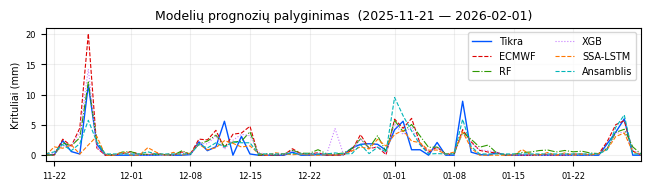

In [921]:
plot_prognozes_matplotlib(df_ensemble, MODEL_COLS_ENS, nuo='2025-11-21', iki='2026-02-01')